In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    recall_score, precision_score, fbeta_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
N_OUTER_FOLDS = 5
THRESHOLD_RANGE = np.arange(0.10, 0.91, 0.01)
TEMPORAL_CUTOFF = '2024-01-01'

FINAL_FEATURES = [
    'rain_rangiwahia_maxhr_lag1',
    'rain_rangiwahia_total',
    'rain_mangaone_valley_maxhr_lag1',
    'rain_cheltenham_maxhr_lag1',
    'rain_halcombe_total',
    'rain_halcombe_maxhr_lag1',
    'wt_almadale_min_lag1',
    'flow_almadale_min_lag3',
    'flow_almadale_mean_lag2',
    'rain_heavy_count_7d',
]

RAINFALL_FEATURES = [
    'rain_rangiwahia_maxhr_lag1',
    'rain_mangaone_valley_maxhr_lag1',
    'rain_cheltenham_maxhr_lag1',
    'rain_halcombe_maxhr_lag1',
]

OTHER_FEATURES = [
    'rain_rangiwahia_total',
    'rain_halcombe_total',
    'wt_almadale_min_lag1',
    'flow_almadale_min_lag3',
    'flow_almadale_mean_lag2',
    'rain_heavy_count_7d',
]

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('features_labelled.csv', index_col=0, parse_dates=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Label counts:\n{df['label'].value_counts().to_string()}")

X = df[FINAL_FEATURES].copy()
y = df['label'].copy()
print(f"\nX shape: {X.shape} | Unsafe samples: {y.sum()}")

Shape: (485, 60)
Date range: 2005-07-13 to 2026-04-30
Label counts:
label
0.0    408
1.0     77

X shape: (485, 10) | Unsafe samples: 77.0


In [2]:
# ── Pipeline ──────────────────────────────────────────────────────────────────
def make_gb_pipeline() -> Pipeline:
    preprocessor = ColumnTransformer([
        ('rain',  SimpleImputer(strategy='constant', fill_value=0), RAINFALL_FEATURES),
        ('other', SimpleImputer(strategy='median'),                  OTHER_FEATURES),
    ], remainder='drop')
    return Pipeline([
        ('prep',  preprocessor),
        ('scale', StandardScaler()),
        ('clf',   GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            random_state=RANDOM_STATE,
        )),
    ])

def find_best_threshold(y_true, y_proba, beta=2.0):
    best_t, best_score = 0.5, -1.0
    for t in THRESHOLD_RANGE:
        y_pred = (y_proba >= t).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        if score > best_score:
            best_score, best_t = score, round(float(t), 2)
    return best_t, best_score

def compute_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'unsafe_recall':     recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'unsafe_precision':  precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f2':                fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0),
        'roc_auc':           roc_auc_score(y_true, y_proba),
        'pr_auc':            average_precision_score(y_true, y_proba),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    }

print("Pipeline ready.")

Pipeline ready.


In [3]:
# ── 5-Fold Cross Validation ───────────────────────────────────────────────────
outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=False)
cv_rows = []

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    gb_pipe = make_gb_pipeline()
    gb_pipe.fit(X_train, y_train)
    gb_proba = gb_pipe.predict_proba(X_val)[:, 1]
    gb_threshold, _ = find_best_threshold(y_val.values, gb_proba)
    gb_metrics = compute_metrics(y_val.values, gb_proba, gb_threshold)
    cv_rows.append({'fold': fold_idx, 'threshold': gb_threshold, **gb_metrics})

    print(f"Fold {fold_idx} | recall={gb_metrics['unsafe_recall']:.3f} "
          f"f2={gb_metrics['f2']:.3f} auc={gb_metrics['roc_auc']:.3f} "
          f"t={gb_threshold:.2f}")

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv('gb_cv_results.csv', index=False)
print("\n── CV Summary ──")
print(cv_df[['unsafe_recall','unsafe_precision','f2','roc_auc','balanced_accuracy']].agg(['mean','std']).round(3))

Fold 1 | recall=0.533 f2=0.563 auc=0.892 t=0.10
Fold 2 | recall=0.733 f2=0.625 auc=0.812 t=0.10
Fold 3 | recall=0.800 f2=0.674 auc=0.807 t=0.13
Fold 4 | recall=0.625 f2=0.602 auc=0.857 t=0.13
Fold 5 | recall=0.562 f2=0.556 auc=0.788 t=0.11

── CV Summary ──
      unsafe_recall  unsafe_precision     f2  roc_auc  balanced_accuracy
mean          0.651             0.518  0.604    0.831              0.759
std           0.113             0.133  0.048    0.042              0.024


In [4]:
# ── Tune GB with better hyperparameters ───────────────────────────────────────
from sklearn.model_selection import GridSearchCV

def make_gb_tuned(n_estimators=200, learning_rate=0.05,
                  max_depth=4, subsample=0.8, min_samples_leaf=5):
    preprocessor = ColumnTransformer([
        ('rain',  SimpleImputer(strategy='constant', fill_value=0), RAINFALL_FEATURES),
        ('other', SimpleImputer(strategy='median'),                  OTHER_FEATURES),
    ], remainder='drop')
    return Pipeline([
        ('prep',  preprocessor),
        ('scale', StandardScaler()),
        ('clf',   GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
        )),
    ])

# Grid search inside CV
param_grid = {
    'clf__n_estimators':    [100, 200],
    'clf__learning_rate':   [0.05, 0.1],
    'clf__max_depth':       [3, 4],
    'clf__min_samples_leaf':[3, 5],
}

outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=False)
inner_cv = StratifiedKFold(n_splits=3, shuffle=False)

cv_rows_tuned = []

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    gs = GridSearchCV(
        make_gb_tuned(),
        param_grid=param_grid,
        cv=inner_cv,
        scoring='f1',
        refit=True,
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    best_params = gs.best_params_

    gb_proba = gs.predict_proba(X_val)[:, 1]
    gb_threshold, _ = find_best_threshold(y_val.values, gb_proba)
    gb_metrics = compute_metrics(y_val.values, gb_proba, gb_threshold)
    cv_rows_tuned.append({'fold': fold_idx, 'threshold': gb_threshold, **gb_metrics})

    print(f"Fold {fold_idx} | recall={gb_metrics['unsafe_recall']:.3f} "
          f"f2={gb_metrics['f2']:.3f} auc={gb_metrics['roc_auc']:.3f} "
          f"t={gb_threshold:.2f} | best={best_params}")

cv_tuned_df = pd.DataFrame(cv_rows_tuned)
print("\n── Tuned GB CV Summary ──")
print(cv_tuned_df[['unsafe_recall','unsafe_precision','f2',
                    'roc_auc','balanced_accuracy']].agg(['mean','std']).round(3))

Fold 1 | recall=0.733 f2=0.688 auc=0.881 t=0.13 | best={'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Fold 2 | recall=0.733 f2=0.679 auc=0.814 t=0.26 | best={'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}
Fold 3 | recall=0.800 f2=0.652 auc=0.799 t=0.13 | best={'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}
Fold 4 | recall=0.750 f2=0.706 auc=0.888 t=0.10 | best={'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}
Fold 5 | recall=0.625 f2=0.588 auc=0.768 t=0.11 | best={'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}

── Tuned GB CV Summary ──
      unsafe_recall  unsafe_precision     f2  roc_auc  balanced_accuracy
mean          0.728             0.499  0.663    0.830              0.792
std           0.064             0.

Hold-out train: (393, 10) | test: (92, 10)
Exceedances in test set: 11

── GB Hold-out results (2024+), threshold=0.19 ──
  unsafe_recall             0.727
  unsafe_precision          0.348
  f2                        0.597
  roc_auc                   0.811
  pr_auc                    0.549
  balanced_accuracy         0.771


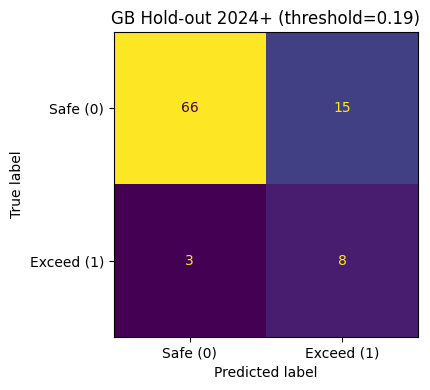

In [5]:
# ── Final hold-out 2024+ with best typical params ─────────────────────────────
# Most common best params across folds: lr=0.05-0.1, depth=3-4, leaf=3, n=100-200
# Use these as final fixed params for hold-out

final_preprocessor = ColumnTransformer([
    ('rain',  SimpleImputer(strategy='constant', fill_value=0), RAINFALL_FEATURES),
    ('other', SimpleImputer(strategy='median'),                  OTHER_FEATURES),
], remainder='drop')

gb_final = Pipeline([
    ('prep',  final_preprocessor),
    ('scale', StandardScaler()),
    ('clf',   GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=3,
        subsample=0.8,
        random_state=RANDOM_STATE,
    )),
])

train_mask = df.index < TEMPORAL_CUTOFF
X_ho_train, X_ho_test = X[train_mask], X[~train_mask]
y_ho_train, y_ho_test = y[train_mask], y[~train_mask]

print(f"Hold-out train: {X_ho_train.shape} | test: {X_ho_test.shape}")
print(f"Exceedances in test set: {int(y_ho_test.sum())}")

gb_final.fit(X_ho_train, y_ho_train)
gb_ho_proba = gb_final.predict_proba(X_ho_test)[:, 1]
gb_ho_thresh, _ = find_best_threshold(y_ho_test.values, gb_ho_proba)
gb_ho_metrics = compute_metrics(y_ho_test.values, gb_ho_proba, gb_ho_thresh)

print(f"\n── GB Hold-out results (2024+), threshold={gb_ho_thresh} ──")
for k, v in gb_ho_metrics.items():
    print(f"  {k:25} {v:.3f}")

# Confusion matrix
y_ho_pred = (gb_ho_proba >= gb_ho_thresh).astype(int)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_ho_test, y_ho_pred,
    display_labels=["Safe (0)", "Exceed (1)"],
    ax=ax, colorbar=False
)
ax.set_title(f"GB Hold-out 2024+ (threshold={gb_ho_thresh})")
plt.tight_layout()
plt.savefig('gb_confusion_matrix.png', dpi=150)
plt.show()